# 과제 3: Word2Vec 구현 (Skip-gram)
- **배점**: 20점 (100점 만점 중 20점, 전체 과제 비중 30%)
- `(1) 총 7개 빈칸 (각 1점), (2) 실행 결과 - Loss 감소 확인 및 임베딩 시각화 출력 (6점), (3) 하이퍼파라미터 변경 또는 추가 설명 (7점)`
- 하이퍼파라미터 튜닝의 경우: "embedding_size를 2가 아닌 다른 숫자(예: 10, 50)로 변경하고, window_size나 epoch를 조절해 보며 결과가 어떻게 달라지는지 한 줄로 서술해 보세요."



- **목표**: 라이브러리(Gensim 등)를 최소화하고 PyTorch를 활용하여 Word2Vec(Skip-gram)의 기본 원리를 코드로 구현합니다. 튜토리얼 형식으로 중간중간 결과물을 확인하며 진행하세요.


# Step 0: 라이브러리 임포트

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


# Step 1: Toy Dataset 준비 및 단어 사전(Vocabulary) 구축
간단한 문장들로 구성된 코퍼스를 만들고, 단어와 인덱스를 매핑하는 사전을 만듭니다.


In [3]:
corpus = [
    "he is a king",
    "she is a queen",
    "he is a man",
    "she is a woman",
    "seoul is korea capital",
    "tokyo is japan capital",
    "paris is france capital"
]

# 토큰화 및 단어 중복 제거
words = " ".join(corpus).split()
word_list = list(set(words)) # 👈 단어 중복을 제거하는 파이썬 내장 함수를 사용하세요.

word_dict = {w: i for i, w in enumerate(word_list)}
number_dict = {i: w for i, w in enumerate(word_list)}
vocab_size = len(word_dict)

print("단어 사전 크기:", vocab_size)
print("단어-인덱스 매핑:", word_dict)

단어 사전 크기: 15
단어-인덱스 매핑: {'seoul': 0, 'she': 1, 'is': 2, 'king': 3, 'queen': 4, 'france': 5, 'a': 6, 'japan': 7, 'paris': 8, 'korea': 9, 'capital': 10, 'woman': 11, 'tokyo': 12, 'man': 13, 'he': 14}


# Step 2: Skip-gram 학습 데이터 생성
중심 단어(Center Word)를 바탕으로 윈도우 크기 내의 주변 단어(Context Word)를 예측하도록 (Target, Context) 쌍을 구성합니다.

In [4]:
window_size = 1
skip_grams = []

for sentence in corpus:
    tokens = sentence.split()
    for i in range(len(tokens)):
        target = word_dict[tokens[i]]
        # 윈도우 사이즈 내의 주변 단어 찾기
        for j in range(max(0, i - window_size), min(len(tokens), i + window_size + 1)):
            if i != j:
                context = word_dict[tokens[j]] # 👈 tokens 리스트에서 주변 단어의 인덱스(j)를 참조해 사전에 넣으세요.
                skip_grams.append([target, context])

print(f"생성된 학습 데이터 개수: {len(skip_grams)}")
print("첫 5개 데이터 (Target, Context):", skip_grams[:5])

생성된 학습 데이터 개수: 42
첫 5개 데이터 (Target, Context): [[14, 2], [2, 14], [2, 6], [6, 2], [6, 3]]


# Step 3: Word2Vec (Skip-gram) 모델 정의
PyTorch를 이용하여 단어를 임베딩 차원으로 축소시키는 은닉층($W$)과 다시 단어 사전 크기로 복원하는 출력층($W'$)을 정의합니다.

In [5]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        super(Word2Vec, self).__init__()
        # V -> D (Projection / Embedding)
        self.W = nn.Linear(vocab_size, embedding_size, bias=False) # 👈 vocab_size와 embedding_size를 입력하세요.
        # D -> V (Output)
        self.WT = nn.Linear(embedding_size, vocab_size, bias=False) # 👈 embedding_size와 vocab_size를 입력하세요.

    def forward(self, X):
        hidden_layer = self.W(X)
        output_layer = self.WT(hidden_layer)
        return output_layer

# 2차원 그래프에 시각화하기 위해 임베딩 사이즈는 2로 설정합니다.
embedding_size = 2
model = Word2Vec(vocab_size, embedding_size)


# Step 4: 모델 학습 준비 및 One-hot Encoding

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

def get_one_hot(word_idx, vocab_size):
    x = torch.zeros(vocab_size)
    x[word_idx] = 1.0 # 👈 해당 word_idx 위치를 1.0으로 설정하여 원핫 벡터를 완성하세요.
    return x

# 원핫 인코딩 결과 중간 확인
print("One-hot vector for index 0:", get_one_hot(0, vocab_size))

One-hot vector for index 0: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


# Step 5: 모델 학습 (Training)
데이터를 순회하며 가중치를 업데이트하는 루프입니다.

In [7]:
epochs = 5000
losses = []

for epoch in range(epochs):
    loss_val = 0
    for target, context in skip_grams:
        # 중심 단어의 원핫 벡터 생성
        x = get_one_hot(target, vocab_size)
        # 주변 단어의 실제 정답 인덱스
        y_true = torch.tensor([context], dtype=torch.long)

        optimizer.zero_grad()
        y_pred = model(x)

        loss = criterion(y_pred.unsqueeze(0), y_true)
        loss.backward() # 👈 역전파 수행 (backward)
        optimizer.step() # 👈 가중치 업데이트 (step)

        loss_val += loss.item()

    avg_loss = loss_val / len(skip_grams)
    losses.append(avg_loss)
    if epoch % 1000 == 0:
        print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}')

Epoch: 0, Loss: 2.7158
Epoch: 1000, Loss: 1.1441
Epoch: 2000, Loss: 1.1426
Epoch: 3000, Loss: 1.1418
Epoch: 4000, Loss: 1.1412


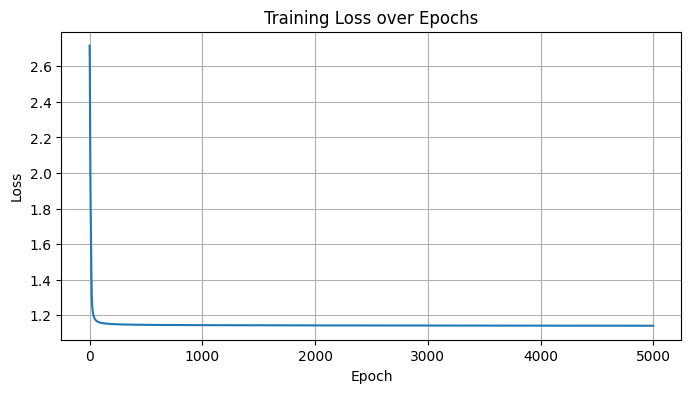

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Step 6: 임베딩 결과 확인 및 시각화
학습이 끝난 후, 입력층-은닉층 사이의 가중치 행렬(W)을 단어의 임베딩 벡터로 사용합니다.

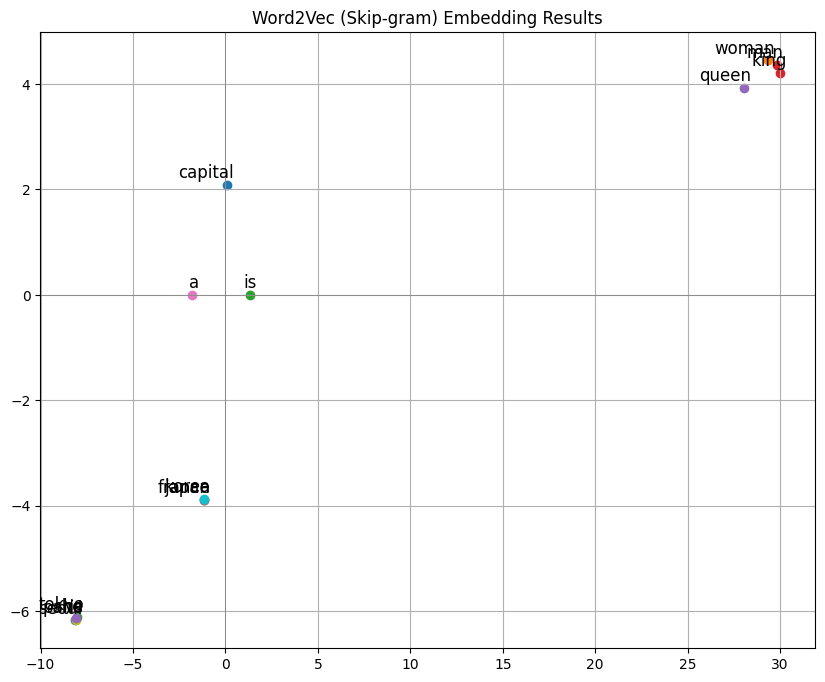

In [9]:
# 가중치 텐서를 numpy 배열로 변환
W_embed = model.W.weight.data.numpy().T

plt.figure(figsize=(10, 8))
for i, word in enumerate(word_list):
    x, y = W_embed[i][0], W_embed[i][1]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom', fontsize=12)

plt.title("Word2Vec (Skip-gram) Embedding Results")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid(True)
plt.show()

# Step 7: 하이퍼파라미터 변경 및 결과 분석
embedding_size, window_size, epoch 등을 조정하여 모델의 학습 양상을 비교합니다.

--- 새 모델 학습 시작 (Embed: 10, Window: 3) ---
Epoch: 1000, Loss: 1.7242
Epoch: 2000, Loss: 1.7202
Epoch: 3000, Loss: 1.7159


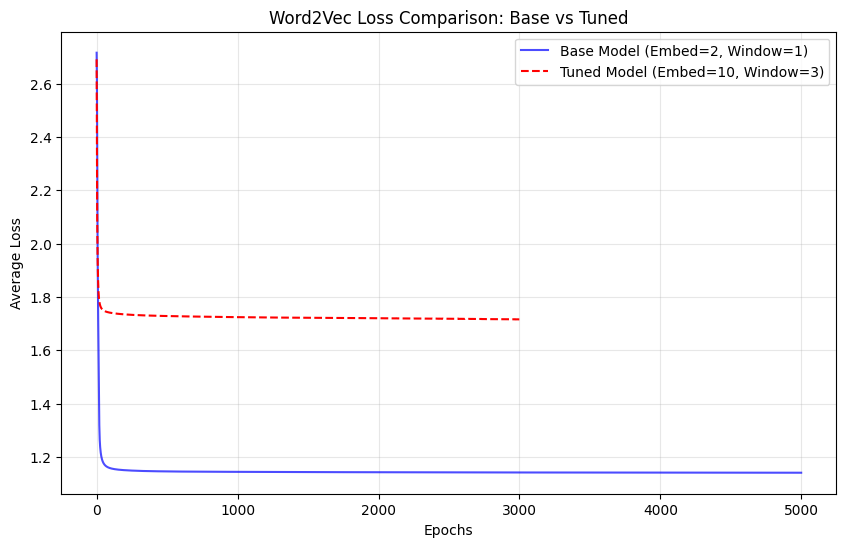


최종 결과 분석:
- 기존 모델 최종 Loss: 1.1409
- 튜닝 모델 최종 Loss: 1.7159


In [16]:
# 하이퍼파라미터 설정 변경
tuning_embedding_size = 10
tuning_window_size = 3
tuning_epochs = 3000

# 데이터 재구성 (window_size 반영)
tuning_skip_grams = []
for sentence in corpus:
    tokens = sentence.split()
    for i in range(len(tokens)):
        target = word_dict[tokens[i]]
        for j in range(max(0, i - tuning_window_size), min(len(tokens), i + tuning_window_size + 1)):
            if i != j:
                context = word_dict[tokens[j]]
                tuning_skip_grams.append([target, context])

# 모델 및 옵티마이저 초기화
tuning_model = Word2Vec(vocab_size, tuning_embedding_size)
tuning_criterion = nn.CrossEntropyLoss()
tuning_optimizer = optim.Adam(tuning_model.parameters(), lr=0.01)
tuning_losses = []

print(f"--- 새 모델 학습 시작 (Embed: {tuning_embedding_size}, Window: {tuning_window_size}) ---")

for epoch in range(tuning_epochs):
    loss_val = 0
    for target, context in tuning_skip_grams:
        # 중심 단어 원핫 인코딩
        x = get_one_hot(target, vocab_size)
        # 주변 단어 인덱스
        y_true = torch.tensor([context], dtype=torch.long)

        tuning_optimizer.zero_grad()
        y_pred = tuning_model(x)

        loss = tuning_criterion(y_pred.unsqueeze(0), y_true)
        loss.backward()
        tuning_optimizer.step()

        loss_val += loss.item()

    avg_loss = loss_val / len(tuning_skip_grams)
    tuning_losses.append(avg_loss)

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch: {epoch + 1}, Loss: {avg_loss:.4f}")

# --- 3. 기존 모델의 Loss(losses)와 새 모델의 Loss(tuning_losses) 비교 시각화 ---
plt.figure(figsize=(10, 6))

# 기존 모델 (Step 5에서 저장된 losses 변수 사용)
plt.plot(losses, label='Base Model (Embed=2, Window=1)', color='blue', alpha=0.7)

# 새 모델 (방금 학습한 tuning_losses)
plt.plot(tuning_losses, label=f'Tuned Model (Embed={tuning_embedding_size}, Window={tuning_window_size})',
         color='red', linestyle='--')

plt.title("Word2Vec Loss Comparison: Base vs Tuned")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n최종 결과 분석:")
print(f"- 기존 모델 최종 Loss: {losses[-1]:.4f}")
print(f"- 튜닝 모델 최종 Loss: {tuning_losses[-1]:.4f}")

# Step 7-1: 고차원 임베딩 모델을 t-SNE를 이용하여 시각화하기

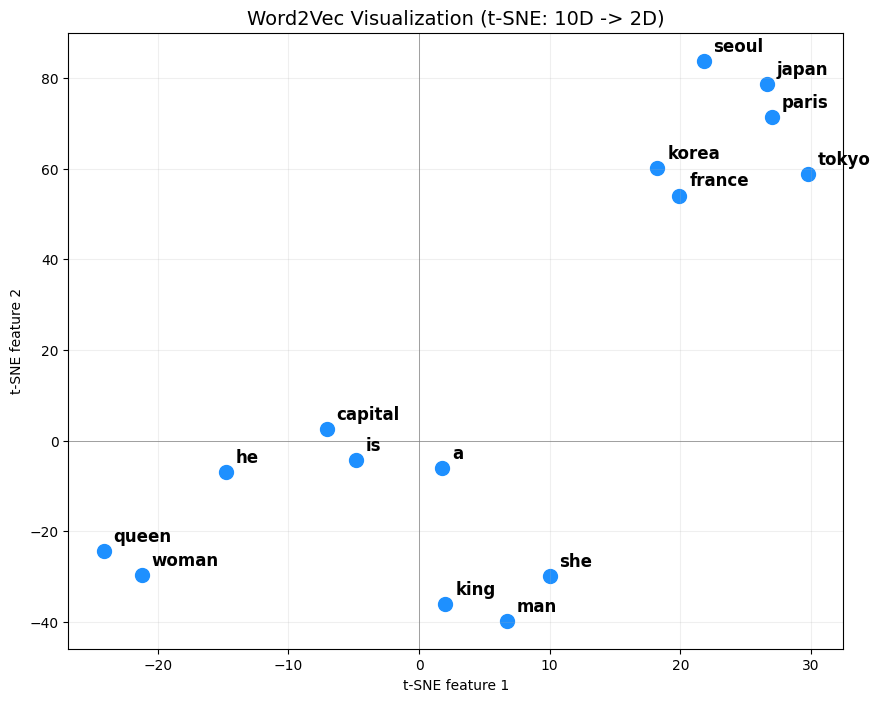

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

# --- 1. 학습된 10차원 임베딩 가중치 추출 ---
W_10d = tuning_model.W.weight.data.numpy().T

# --- 2. t-SNE를 이용한 차원 축소 (10D -> 2D) ---
# n_samples가 15개이므로 perplexity는 보통 (n_samples - 1) / 3 보다 작아야 합니다.
# 여기서는 아주 작은 값인 3~5 정도로 설정합니다.
tsne = TSNE(n_components=2, perplexity=3, random_state=42, learning_rate='auto', init='pca')
W_tsne = tsne.fit_transform(W_10d)

# --- 3. 시각화 ---
plt.figure(figsize=(10, 8))

for i, word in enumerate(word_list):
    x, y = W_tsne[i][0], W_tsne[i][1]
    plt.scatter(x, y, color='dodgerblue', s=100)
    # 단어 라벨 표시
    plt.annotate(word, (x, y), xytext=(7, 7), textcoords='offset points',
                 fontsize=12, fontweight='bold')

plt.title("Word2Vec Visualization (t-SNE: 10D -> 2D)", fontsize=14)
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid(True, alpha=0.2)
plt.show()